In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import ks_2samp

data = pd.read_csv("../../../data/raw/kathmandu_full_raw_2023_2024.csv")
data["time"] = pd.to_datetime(data["time"])
data = data.sort_values("time").reset_index(drop=True)
data = data.set_index("time")

15 — Time-Series Decomposition: Splits the PM2.5 series into trend, seasonal (daily), and residual components to see how much of the variation is structural versus random.

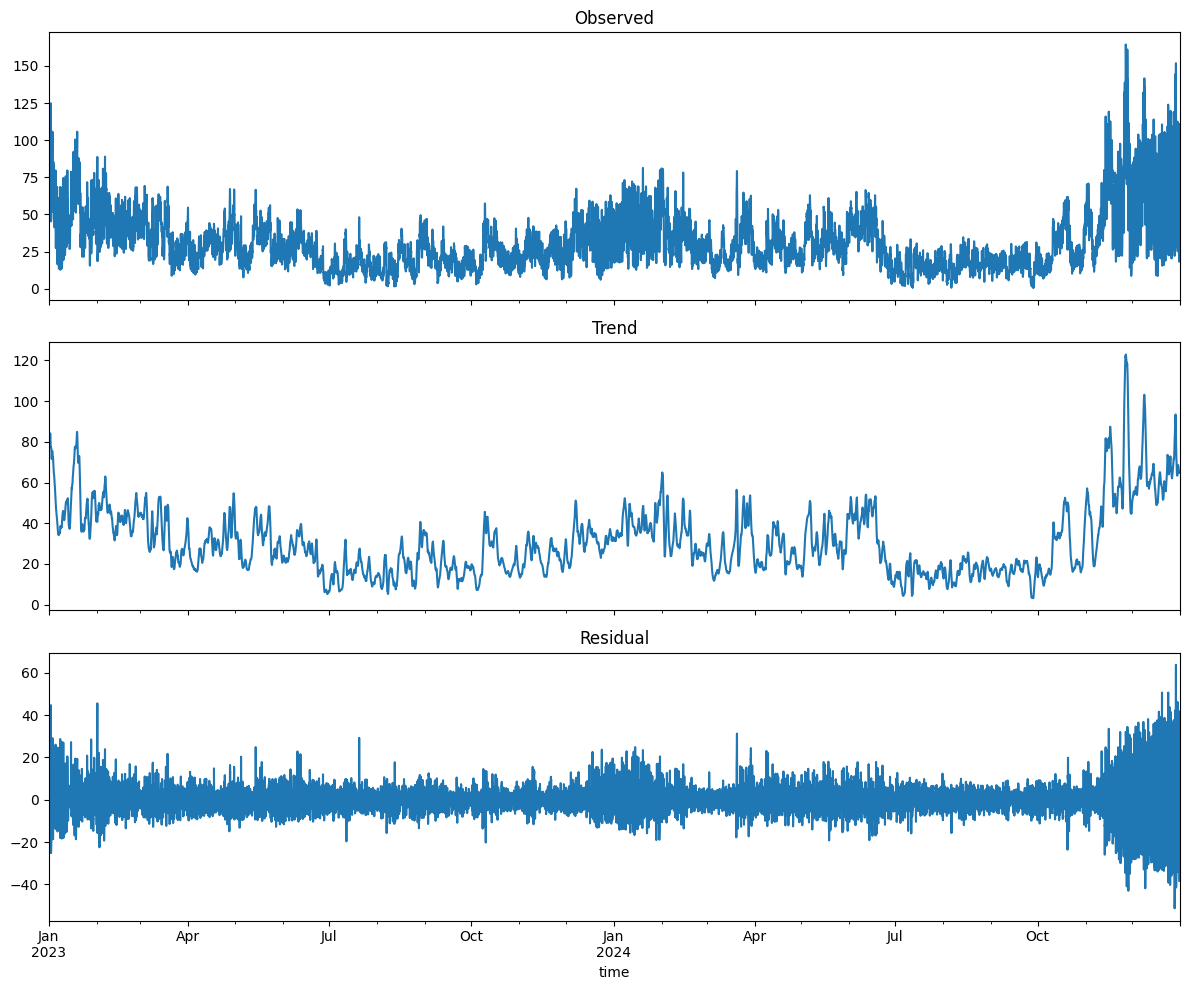

In [4]:
result = seasonal_decompose(data["pm2_5"], model="additive", period=24)

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
result.observed.plot(ax=axes[0], title="Observed")
result.trend.plot(ax=axes[1], title="Trend")
result.resid.plot(ax=axes[2], title="Residual")
plt.tight_layout()
plt.show()

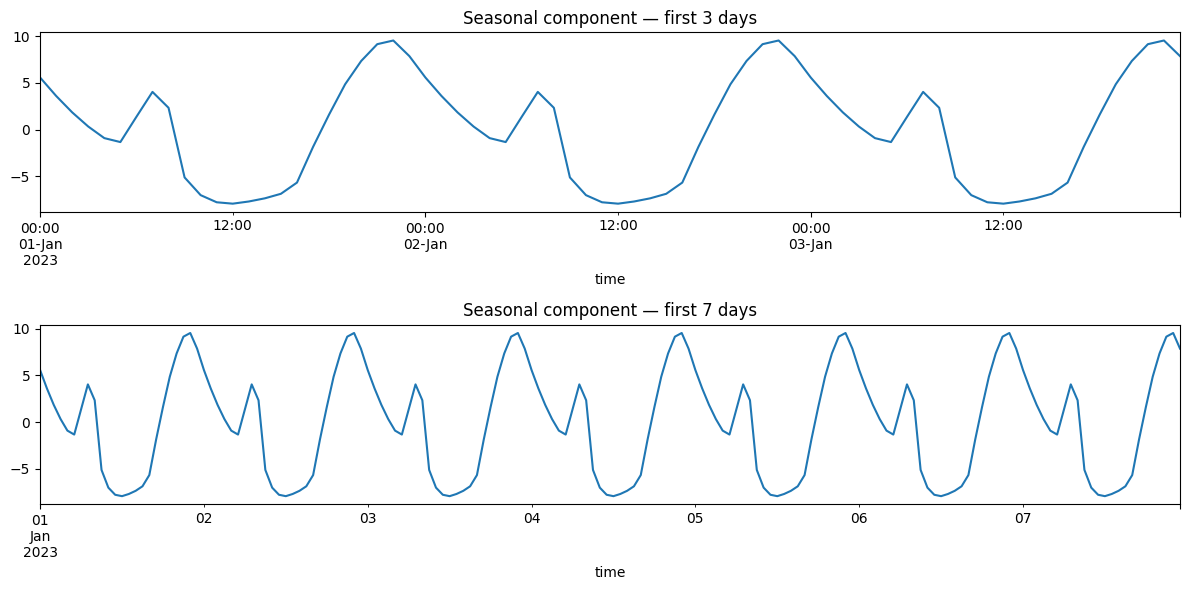

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
result.seasonal.iloc[:24*3].plot(ax=axes[0], title="Seasonal component — first 3 days")
result.seasonal.iloc[:24*7].plot(ax=axes[1], title="Seasonal component — first 7 days")
plt.tight_layout()
plt.show()

16 — Stationarity Testing (ADF/KPSS): Checks whether the statistical properties of PM2.5 (mean, variance) stay constant over time, which determines whether ARIMA-family models need differencing.


In [6]:
adf_stat, adf_p, *_ = adfuller(data["pm2_5"])
print(f"ADF Statistic: {adf_stat:.4f}, p-value: {adf_p:.4f}")
print("ADF conclusion:", "Stationary" if adf_p < 0.05 else "Non-stationary")

kpss_stat, kpss_p, *_ = kpss(data["pm2_5"], regression="c", nlags="auto")
print(f"\nKPSS Statistic: {kpss_stat:.4f}, p-value: {kpss_p:.4f}")
print("KPSS conclusion:", "Non-stationary" if kpss_p < 0.05 else "Stationary")

ADF Statistic: -5.8642, p-value: 0.0000
ADF conclusion: Stationary

KPSS Statistic: 1.4618, p-value: 0.0100
KPSS conclusion: Non-stationary


C:\Users\adars\AppData\Local\Temp\ipykernel_30984\3748553825.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(data["pm2_5"], regression="c", nlags="auto")


17 — Pearson Correlation: Measures the strength of linear relationships between PM2.5 and every other numeric variable.

In [7]:
numeric_cols = data.select_dtypes(include=[np.number]).columns
pearson_corr = data[numeric_cols].corr(method="pearson")

print("Pearson correlation with pm2_5:")
print(pearson_corr["pm2_5"].sort_values(ascending=False))

Pearson correlation with pm2_5:
pm2_5                   1.000000
pm10                    0.952177
sulphur_dioxide         0.753975
carbon_monoxide         0.620771
nitrogen_dioxide        0.493972
surface_pressure        0.175934
relative_humidity_2m    0.045576
ozone                  -0.019743
wind_direction_10m     -0.109160
wind_speed_10m         -0.110932
temperature_2m         -0.522716
Name: pm2_5, dtype: float64


18 — Spearman Correlation: Measures monotonic (not necessarily linear) relationships between PM2.5 and other variables, catching patterns Pearson might miss.


In [8]:
spearman_corr = data[numeric_cols].corr(method="spearman")

print("Spearman correlation with pm2_5:")
print(spearman_corr["pm2_5"].sort_values(ascending=False))

Spearman correlation with pm2_5:
pm2_5                   1.000000
pm10                    0.984206
sulphur_dioxide         0.660291
carbon_monoxide         0.628313
nitrogen_dioxide        0.412267
surface_pressure        0.218198
ozone                   0.050449
relative_humidity_2m   -0.047194
wind_direction_10m     -0.077613
wind_speed_10m         -0.078430
temperature_2m         -0.516114
Name: pm2_5, dtype: float64


19 — Correlation Heatmap: Visualizes the full Pearson correlation matrix across all variables at once, making it easy to spot the strongest relationships.

Pearson correlation matrix:
                      pm2_5  pm10  carbon_monoxide  nitrogen_dioxide  \
pm2_5                  1.00  0.95             0.62              0.49   
pm10                   0.95  1.00             0.58              0.45   
carbon_monoxide        0.62  0.58             1.00              0.82   
nitrogen_dioxide       0.49  0.45             0.82              1.00   
sulphur_dioxide        0.75  0.64             0.68              0.53   
ozone                 -0.02  0.06            -0.44             -0.63   
temperature_2m        -0.52 -0.47            -0.68             -0.56   
relative_humidity_2m   0.05  0.00             0.17              0.32   
wind_speed_10m        -0.11 -0.06            -0.28             -0.37   
wind_direction_10m    -0.11 -0.08            -0.26             -0.29   
surface_pressure       0.18  0.18             0.17              0.02   

                      sulphur_dioxide  ozone  temperature_2m  \
pm2_5                            0.75  -0.0

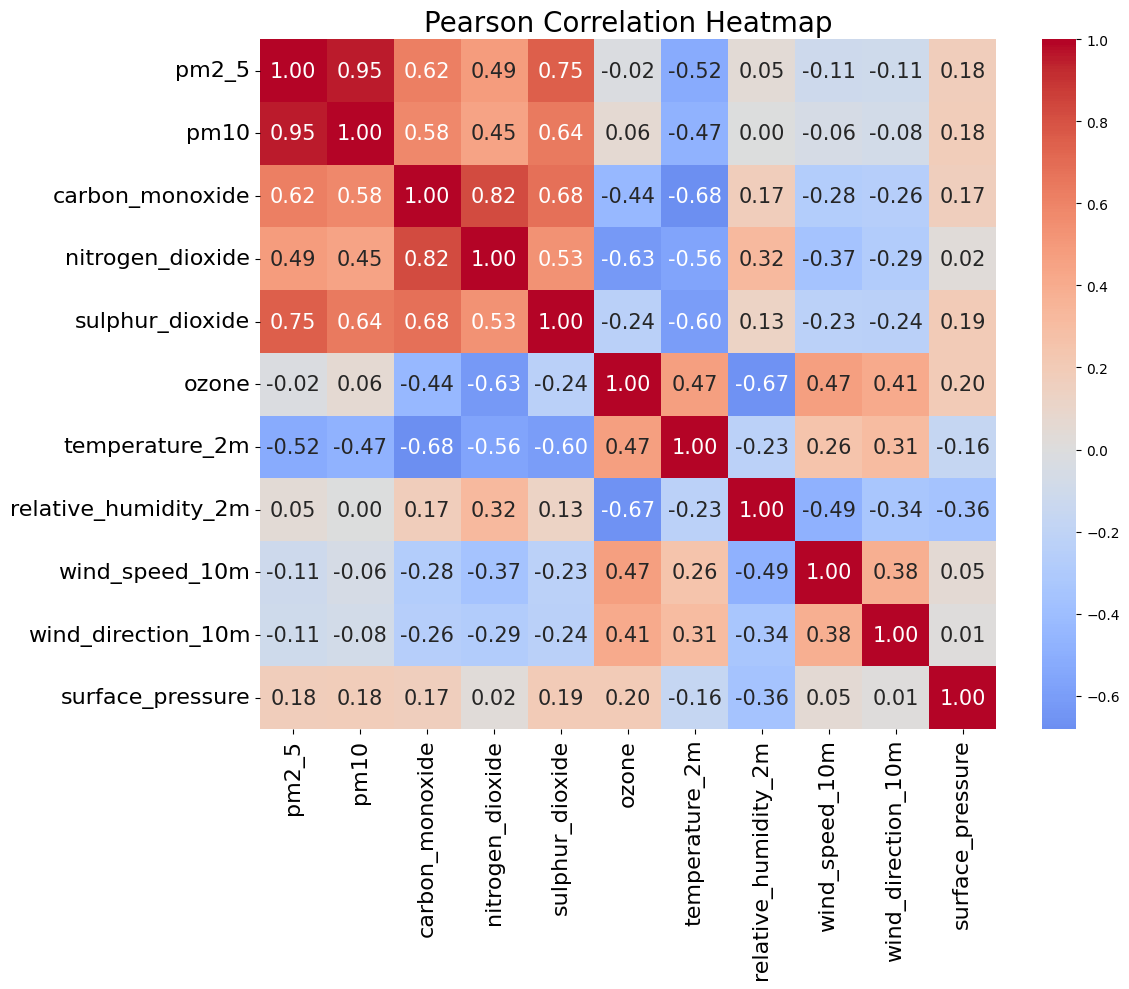

In [28]:
print("Pearson correlation matrix:")
print(pearson_corr.round(2))

plt.figure(figsize=(12, 10))
sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, annot_kws={"size": 15})
plt.title("Pearson Correlation Heatmap", fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.show()

20 — ACF (Autocorrelation Function): Shows how strongly PM2.5 correlates with its own past values at every lag, revealing overall temporal dependency and periodicity.


ACF values (lag 0-168):
lag   0h: 1.0000
lag   1h: 0.9649
lag   2h: 0.9110
lag   3h: 0.8541
lag   4h: 0.7985
lag   5h: 0.7455
lag   6h: 0.6966
lag   7h: 0.6536
lag   8h: 0.6186
lag   9h: 0.5907
lag  10h: 0.5709
lag  11h: 0.5561
lag  12h: 0.5471
lag  13h: 0.5457
lag  14h: 0.5505
lag  15h: 0.5602
lag  16h: 0.5764
lag  17h: 0.5997
lag  18h: 0.6311
lag  19h: 0.6678
lag  20h: 0.7077
lag  21h: 0.7492
lag  22h: 0.7906
lag  23h: 0.8286
lag  24h: 0.8486
lag  25h: 0.8194
lag  26h: 0.7727
lag  27h: 0.7232
lag  28h: 0.6745
lag  29h: 0.6270
lag  30h: 0.5825
lag  31h: 0.5430
lag  32h: 0.5107
lag  33h: 0.4850
lag  34h: 0.4676
lag  35h: 0.4551
lag  36h: 0.4484
lag  37h: 0.4492
lag  38h: 0.4557
lag  39h: 0.4668
lag  40h: 0.4838
lag  41h: 0.5080
lag  42h: 0.5398
lag  43h: 0.5763
lag  44h: 0.6156
lag  45h: 0.6564
lag  46h: 0.6972
lag  47h: 0.7348
lag  48h: 0.7545
lag  49h: 0.7287
lag  50h: 0.6855
lag  51h: 0.6391
lag  52h: 0.5933
lag  53h: 0.5489
lag  54h: 0.5073
lag  55h: 0.4705
lag  56h: 0.4406
lag  57

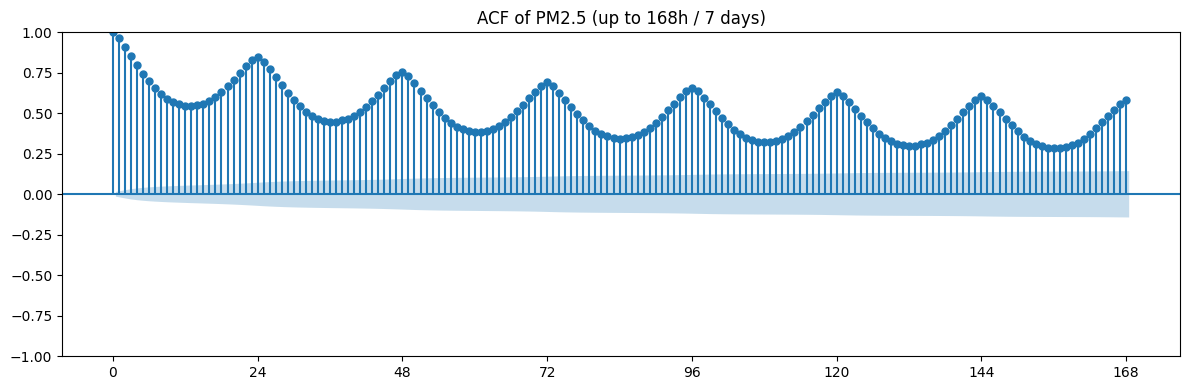

In [8]:
from statsmodels.tsa.stattools import acf

acf_values = acf(data["pm2_5"], nlags=168)

print("ACF values (lag 0-168):")
for lag, val in enumerate(acf_values):
    print(f"lag {lag:>3}h: {val:.4f}")

fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(data["pm2_5"], lags=168, ax=ax)
ax.set_xticks(range(0, 169, 24))

plt.title("ACF of PM2.5 (up to 168h / 7 days)")
plt.tight_layout()
plt.show()

21 — PACF (Partial Autocorrelation Function): Shows the direct correlation between PM2.5 and a specific past lag, with the influence of intermediate lags removed — used to pick which lags actually matter.


PACF values (lag 0-72):
lag  0h: 1.0000
lag  1h: 0.9649
lag  2h: -0.2922
lag  3h: 0.0034
lag  4h: -0.0095
lag  5h: -0.0014
lag  6h: 0.0144
lag  7h: 0.0374
lag  8h: 0.0572
lag  9h: 0.0387
lag 10h: 0.0666
lag 11h: 0.0167
lag 12h: 0.0653
lag 13h: 0.0856
lag 14h: 0.0651
lag 15h: 0.0659
lag 16h: 0.1128
lag 17h: 0.1199
lag 18h: 0.1476
lag 19h: 0.1271
lag 20h: 0.1351
lag 21h: 0.1484
lag 22h: 0.1608
lag 23h: 0.1453
lag 24h: -0.0786
lag 25h: -0.6016
lag 26h: 0.0242
lag 27h: 0.0251
lag 28h: -0.0028
lag 29h: -0.0271
lag 30h: -0.0087
lag 31h: -0.0048
lag 32h: 0.0115
lag 33h: -0.0025
lag 34h: 0.0208
lag 35h: 0.0109
lag 36h: 0.0227
lag 37h: 0.0276
lag 38h: 0.0043
lag 39h: 0.0206
lag 40h: 0.0330
lag 41h: 0.0385
lag 42h: 0.0229
lag 43h: 0.0278
lag 44h: 0.0410
lag 45h: 0.0513
lag 46h: 0.0603
lag 47h: 0.0484
lag 48h: -0.0142
lag 49h: -0.2624
lag 50h: 0.0057
lag 51h: 0.0064
lag 52h: -0.0021
lag 53h: 0.0147
lag 54h: -0.0006
lag 55h: 0.0036
lag 56h: 0.0081
lag 57h: 0.0083
lag 58h: -0.0078
lag 59h: -0.0020


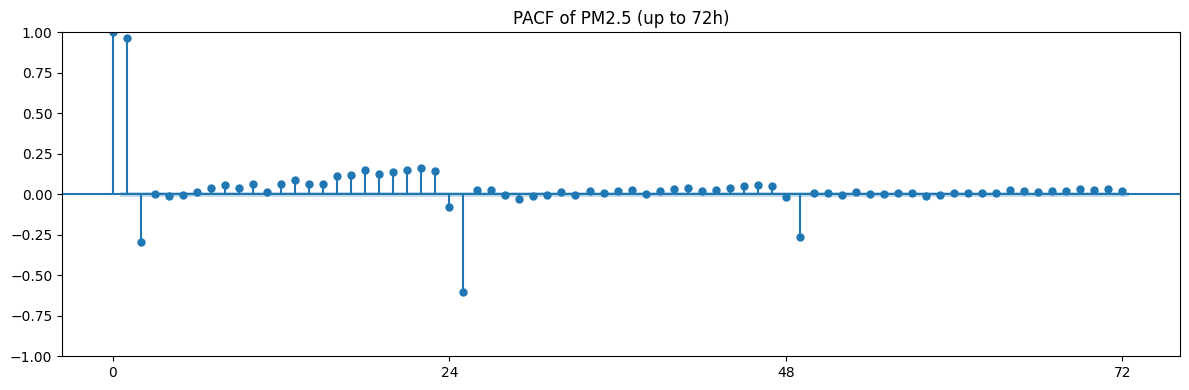

In [9]:
from statsmodels.tsa.stattools import pacf

pacf_values = pacf(data["pm2_5"], nlags=72, method="ywm")

print("PACF values (lag 0-72):")
for lag, val in enumerate(pacf_values):
    print(f"lag {lag:>2}h: {val:.4f}")

fig, ax = plt.subplots(figsize=(12, 4))
plot_pacf(data["pm2_5"], lags=72, method="ywm", ax=ax)
ax.set_xticks(range(0, 73, 24))

plt.title("PACF of PM2.5 (up to 72h)")
plt.tight_layout()
plt.show()

22 — Lag Correlation Analysis: Quantifies PM2.5's correlation with itself at specific, chosen lags (1h, 24h, 168h, etc.) to confirm hourly/daily/weekly dependency.


Lag   1h : 0.9656
Lag   2h : 0.9122
Lag   3h : 0.8557
Lag   6h : 0.6984
Lag  12h : 0.5492
Lag  24h : 0.8559
Lag  48h : 0.7682
Lag 168h : 0.6118


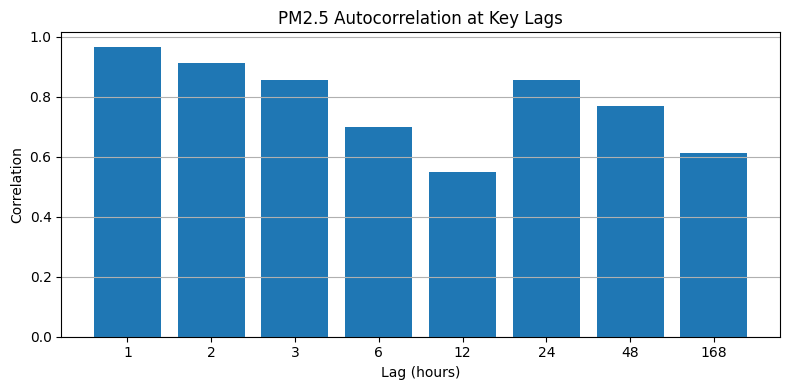

In [10]:
key_lags = [1, 2, 3, 6, 12, 24, 48, 168]
lag_corrs = {lag: data["pm2_5"].autocorr(lag=lag) for lag in key_lags}

for lag, corr in lag_corrs.items():
    print(f"Lag {lag:>3}h : {corr:.4f}")

plt.figure(figsize=(8, 4))
plt.bar([str(l) for l in key_lags], list(lag_corrs.values()))
plt.title("PM2.5 Autocorrelation at Key Lags")
plt.xlabel("Lag (hours)")
plt.ylabel("Correlation")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

23 — Cross-Correlation Analysis: Measures how a weather variable's past values correlate with PM2.5 now, to detect delayed cause-effect relationships (e.g., does temperature change precede pollution change).


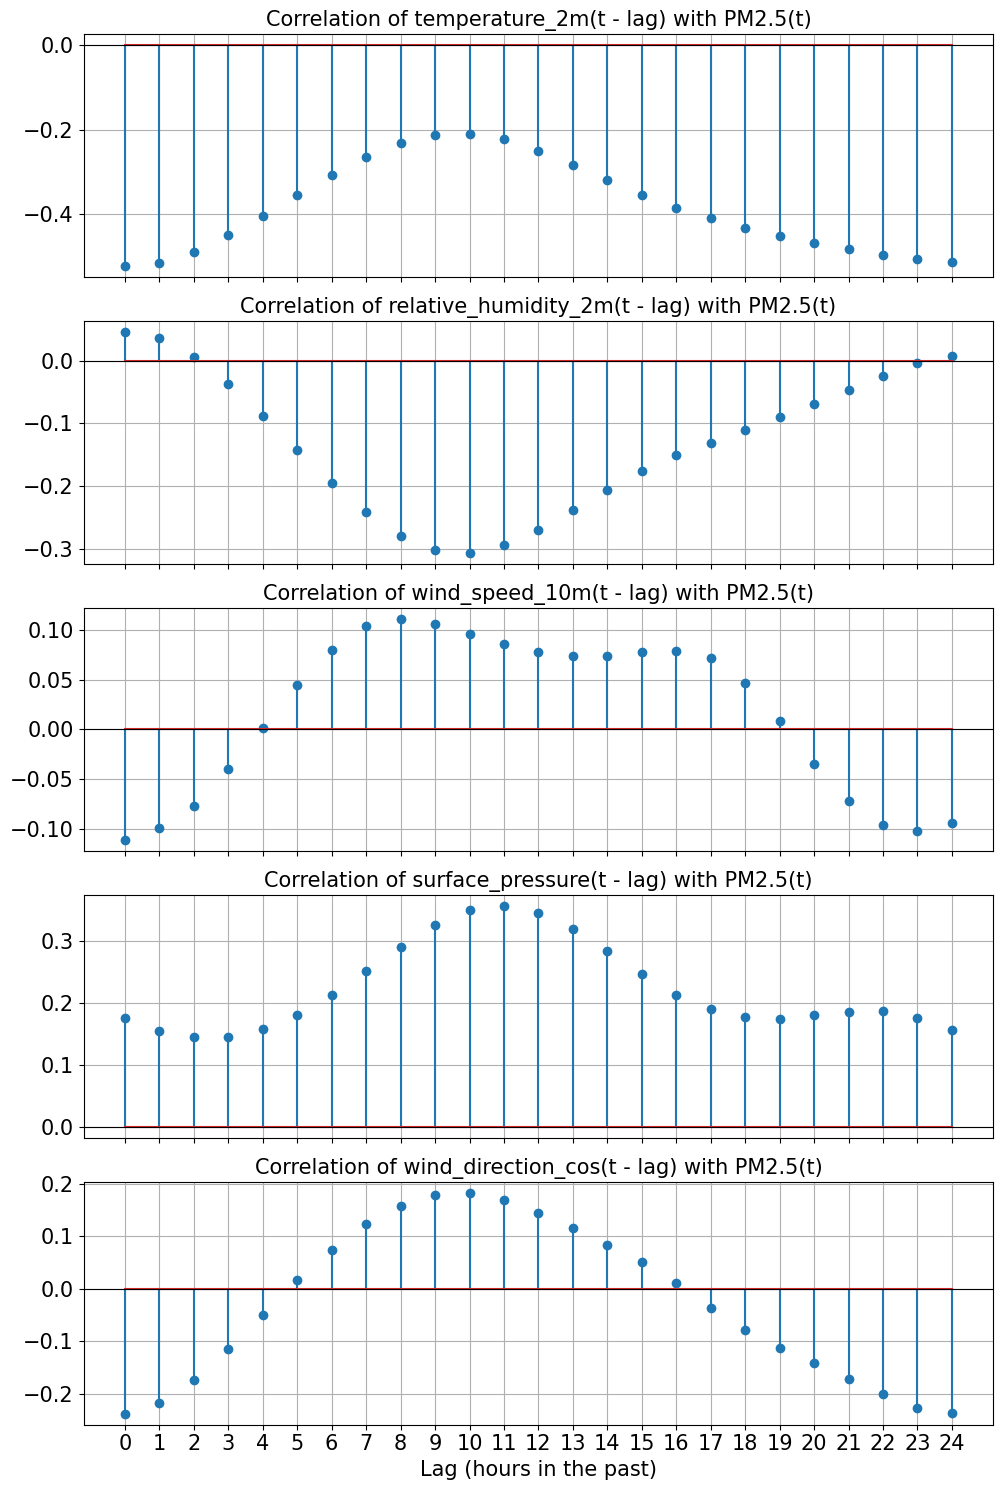

Cross-correlation values (variable at lag k hours in the past vs PM2.5 now):

temperature_2m:
  lag  0h: -0.5227
  lag  1h: -0.5161
  lag  2h: -0.4898
  lag  3h: -0.4499
  lag  4h: -0.4031
  lag  5h: -0.3538
  lag  6h: -0.3061
  lag  7h: -0.2642
  lag  8h: -0.2323
  lag  9h: -0.2133
  lag 10h: -0.2099
  lag 11h: -0.2229
  lag 12h: -0.2496
  lag 13h: -0.2837
  lag 14h: -0.3197
  lag 15h: -0.3540
  lag 16h: -0.3841
  lag 17h: -0.4093
  lag 18h: -0.4317
  lag 19h: -0.4511
  lag 20h: -0.4682
  lag 21h: -0.4830
  lag 22h: -0.4960
  lag 23h: -0.5065
  lag 24h: -0.5122

relative_humidity_2m:
  lag  0h: 0.0456
  lag  1h: 0.0365
  lag  2h: 0.0063
  lag  3h: -0.0377
  lag  4h: -0.0884
  lag  5h: -0.1419
  lag  6h: -0.1948
  lag  7h: -0.2424
  lag  8h: -0.2795
  lag  9h: -0.3022
  lag 10h: -0.3070
  lag 11h: -0.2946
  lag 12h: -0.2696
  lag 13h: -0.2385
  lag 14h: -0.2060
  lag 15h: -0.1758
  lag 16h: -0.1500
  lag 17h: -0.1311
  lag 18h: -0.1102
  lag 19h: -0.0893
  lag 20h: -0.0684
  lag 21h: -

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------
# Prepare variables
# --------------------------------------------
data_corr = data.copy()

# Convert wind direction (degrees) to cosine
wind_rad = np.deg2rad(data_corr["wind_direction_10m"])
data_corr["wind_direction_cos"] = np.cos(wind_rad)

weather_vars = [
    "temperature_2m",
    "relative_humidity_2m",
    "wind_speed_10m",
    "surface_pressure",
    "wind_direction_cos",
]

max_lag = 24

fig, axes = plt.subplots(len(weather_vars), 1, figsize=(10, 15), sharex=True)
all_corrs = {}

for i, var in enumerate(weather_vars):
    lags = range(0, max_lag + 1)
    corrs = [data_corr[var].shift(k).corr(data_corr["pm2_5"]) for k in lags]
    all_corrs[var] = corrs

    axes[i].stem(list(lags), corrs)
    axes[i].set_title(f"Correlation of {var}(t - lag) with PM2.5(t)", fontsize=15)
    axes[i].axhline(0, color="black", linewidth=0.8)
    axes[i].grid(True)
    axes[i].tick_params(axis='both', labelsize=15)

axes[-1].set_xlabel("Lag (hours in the past)", fontsize=15)
axes[-1].set_xticks(range(0, max_lag + 1))

plt.tight_layout()
plt.show()

print("Cross-correlation values (variable at lag k hours in the past vs PM2.5 now):\n")
for var, corrs in all_corrs.items():
    print(f"{var}:")
    for k, c in zip(range(0, max_lag + 1), corrs):
        print(f"  lag {k:>2}h: {c:.4f}")
    print()

In [12]:
# --------------------------------------------
# Collect all correlations
# --------------------------------------------
all_results = []

for var, corrs in all_corrs.items():
    for lag, corr in enumerate(corrs):
        all_results.append((var, lag, corr))

# Sort by absolute correlation (largest first)
all_results.sort(key=lambda x: abs(x[2]), reverse=True)

# Print top 3 of all vars

count = {key: 0 for key in all_corrs.keys()}

for rank, (var, lag, corr) in enumerate(all_results, start=1):
    if count[var] < 3:
        print(f"{rank:>3}. {var:<25} lag {lag:>2}h : {corr:.4f}")
        count[var] = count[var] + 1

  1. temperature_2m            lag  0h : -0.5227
  2. temperature_2m            lag  1h : -0.5161
  3. temperature_2m            lag 24h : -0.5122
 15. surface_pressure          lag 11h : 0.3562
 18. surface_pressure          lag 10h : 0.3492
 19. surface_pressure          lag 12h : 0.3448
 23. relative_humidity_2m      lag 10h : -0.3070
 25. relative_humidity_2m      lag  9h : -0.3022
 26. relative_humidity_2m      lag 11h : -0.2946
 64. wind_speed_10m            lag  0h : -0.1109
 65. wind_speed_10m            lag  8h : 0.1108
 67. wind_speed_10m            lag  9h : 0.1063


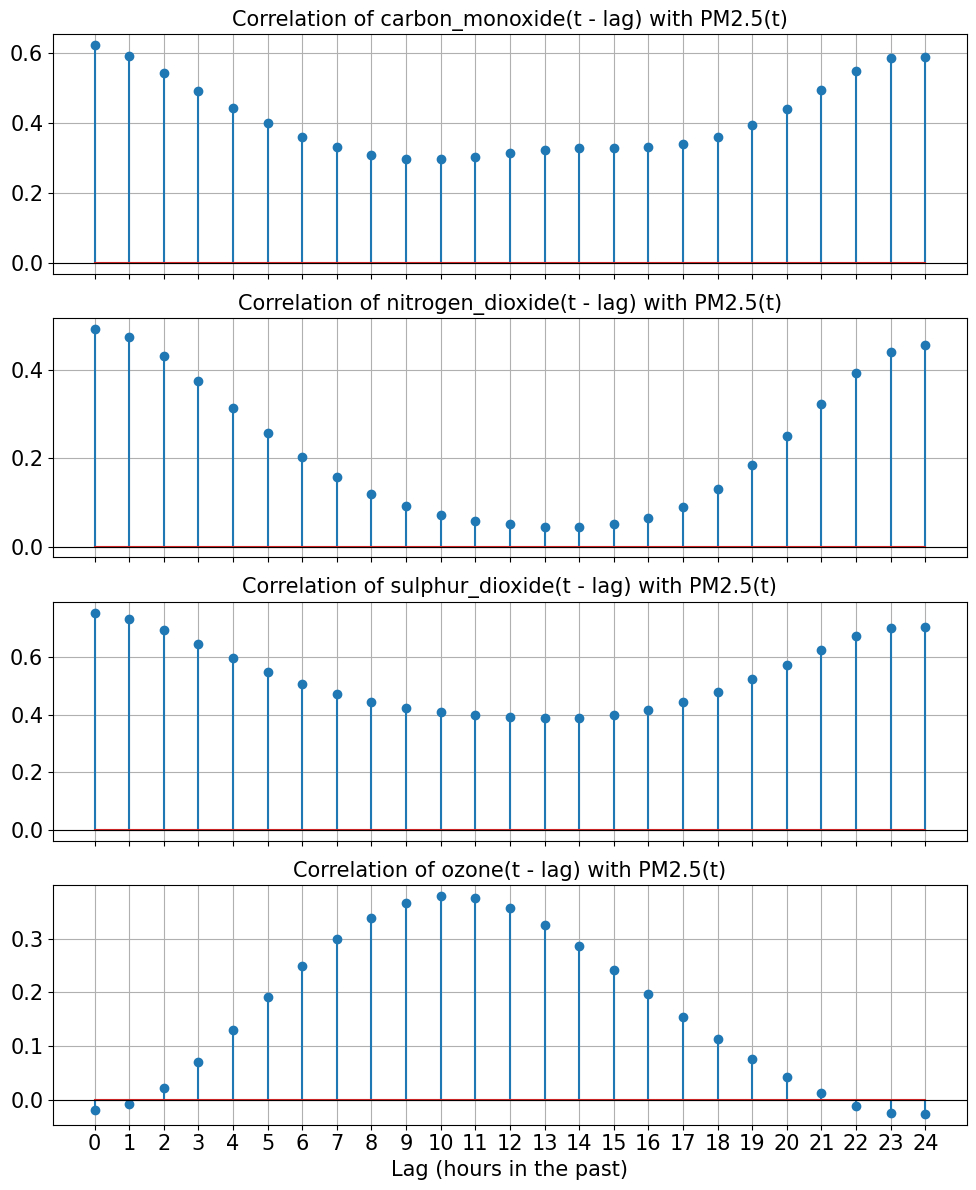

Cross-correlation values (variable at lag k hours in the past vs PM2.5 now):

carbon_monoxide:
  lag  0h: 0.6208
  lag  1h: 0.5893
  lag  2h: 0.5402
  lag  3h: 0.4888
  lag  4h: 0.4414
  lag  5h: 0.3985
  lag  6h: 0.3602
  lag  7h: 0.3293
  lag  8h: 0.3079
  lag  9h: 0.2968
  lag 10h: 0.2959
  lag 11h: 0.3030
  lag 12h: 0.3131
  lag 13h: 0.3213
  lag 14h: 0.3264
  lag 15h: 0.3282
  lag 16h: 0.3299
  lag 17h: 0.3385
  lag 18h: 0.3593
  lag 19h: 0.3930
  lag 20h: 0.4384
  lag 21h: 0.4932
  lag 22h: 0.5486
  lag 23h: 0.5843
  lag 24h: 0.5864

nitrogen_dioxide:
  lag  0h: 0.4940
  lag  1h: 0.4756
  lag  2h: 0.4316
  lag  3h: 0.3750
  lag  4h: 0.3152
  lag  5h: 0.2569
  lag  6h: 0.2032
  lag  7h: 0.1573
  lag  8h: 0.1198
  lag  9h: 0.0911
  lag 10h: 0.0715
  lag 11h: 0.0588
  lag 12h: 0.0502
  lag 13h: 0.0444
  lag 14h: 0.0444
  lag 15h: 0.0510
  lag 16h: 0.0642
  lag 17h: 0.0895
  lag 18h: 0.1301
  lag 19h: 0.1852
  lag 20h: 0.2513
  lag 21h: 0.3235
  lag 22h: 0.3929
  lag 23h: 0.4413
  la

In [41]:
import matplotlib.pyplot as plt

variables = [
    "carbon_monoxide",
    "nitrogen_dioxide",
    "sulphur_dioxide",
    "ozone",
]

max_lag = 24

fig, axes = plt.subplots(len(variables), 1, figsize=(10, 12), sharex=True)
all_corrs = {}

for i, var in enumerate(variables):
    lags = range(0, max_lag + 1)
    corrs = [data_corr[var].shift(k).corr(data_corr["pm2_5"]) for k in lags]
    all_corrs[var] = corrs

    axes[i].stem(list(lags), corrs)
    axes[i].set_title(f"Correlation of {var}(t - lag) with PM2.5(t)", fontsize=15)
    axes[i].axhline(0, color="black", linewidth=0.8)
    axes[i].grid(True)
    axes[i].tick_params(axis='both', labelsize=15)

axes[-1].set_xlabel("Lag (hours in the past)", fontsize=15)
axes[-1].set_xticks(range(0, max_lag + 1))

plt.tight_layout()
plt.show()

print("Cross-correlation values (variable at lag k hours in the past vs PM2.5 now):\n")

for var, corrs in all_corrs.items():
    print(f"{var}:")
    for k, c in zip(range(0, max_lag + 1), corrs):
        print(f"  lag {k:>2}h: {c:.4f}")
    print()

In [14]:
# --------------------------------------------
# Collect all correlations
# --------------------------------------------
all_results = []

for var, corrs in all_corrs.items():
    for lag, corr in enumerate(corrs):
        all_results.append((var, lag, corr))

# Sort by absolute correlation (largest first)
all_results.sort(key=lambda x: abs(x[2]), reverse=True)

# Print top 3 of all vars

count = {key: 0 for key in all_corrs.keys()}

for rank, (var, lag, corr) in enumerate(all_results, start=1):
    if count[var] < 3:
        print(f"{rank:>3}. {var:<25} lag {lag:>2}h : {corr:.4f}")
        count[var] = count[var] + 1

  1. sulphur_dioxide           lag  0h : 0.7540
  2. sulphur_dioxide           lag  1h : 0.7332
  3. sulphur_dioxide           lag 24h : 0.7046
  9. carbon_monoxide           lag  0h : 0.6208
 11. carbon_monoxide           lag  1h : 0.5893
 12. carbon_monoxide           lag 24h : 0.5864
 20. nitrogen_dioxide          lag  0h : 0.4940
 24. nitrogen_dioxide          lag  1h : 0.4756
 26. nitrogen_dioxide          lag 24h : 0.4565
 44. ozone                     lag 10h : 0.3793
 45. ozone                     lag 11h : 0.3756
 47. ozone                     lag  9h : 0.3668
 72. wind_direction_cos        lag  0h : -0.2381
 73. wind_direction_cos        lag 24h : -0.2365
 74. wind_direction_cos        lag 23h : -0.2274
 82. wind_direction_sin        lag  7h : -0.1810
 85. wind_direction_sin        lag  6h : -0.1730
 86. wind_direction_sin        lag  8h : -0.1725


24 — Multicollinearity Analysis (VIF): Detects which predictor variables are highly correlated with each other, which can destabilize linear model coefficients.


In [15]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

predictors = [
    "pm10", "carbon_monoxide", "nitrogen_dioxide", "sulphur_dioxide",
    "ozone", "temperature_2m", "relative_humidity_2m",
    "wind_speed_10m", "surface_pressure"
]

X = data[predictors].dropna()

# Add intercept
X = sm.add_constant(X)

vif_data = pd.DataFrame({
    "feature": X.columns,
    "VIF": [variance_inflation_factor(X.values, i)
            for i in range(X.shape[1])]
})

# Remove the intercept row
vif_data = vif_data[vif_data["feature"] != "const"]

print(vif_data.sort_values("VIF", ascending=False))

                feature       VIF
2       carbon_monoxide  4.878414
3      nitrogen_dioxide  4.702051
5                 ozone  4.473152
1                  pm10  2.715856
7  relative_humidity_2m  2.447285
6        temperature_2m  2.431857
4       sulphur_dioxide  2.407515
8        wind_speed_10m  1.454668
9      surface_pressure  1.294020


25 — Temporal Feature Validation: Confirms that extracted time features (hour, day, month) are correctly and evenly distributed across the dataset.


Hour distribution:
hour
0     731
1     731
2     731
3     731
4     731
5     731
6     731
7     731
8     731
9     731
10    731
11    731
12    731
13    731
14    731
15    731
16    731
17    731
18    731
19    731
20    731
21    731
22    731
23    731
Name: count, dtype: int64

Day-of-week distribution (0=Monday):
day_of_week
0    2520
1    2520
2    2496
3    2496
4    2496
5    2496
6    2520
Name: count, dtype: int64

Month distribution:
month
1     1488
2     1368
3     1488
4     1440
5     1488
6     1440
7     1488
8     1488
9     1440
10    1488
11    1440
12    1488
Name: count, dtype: int64


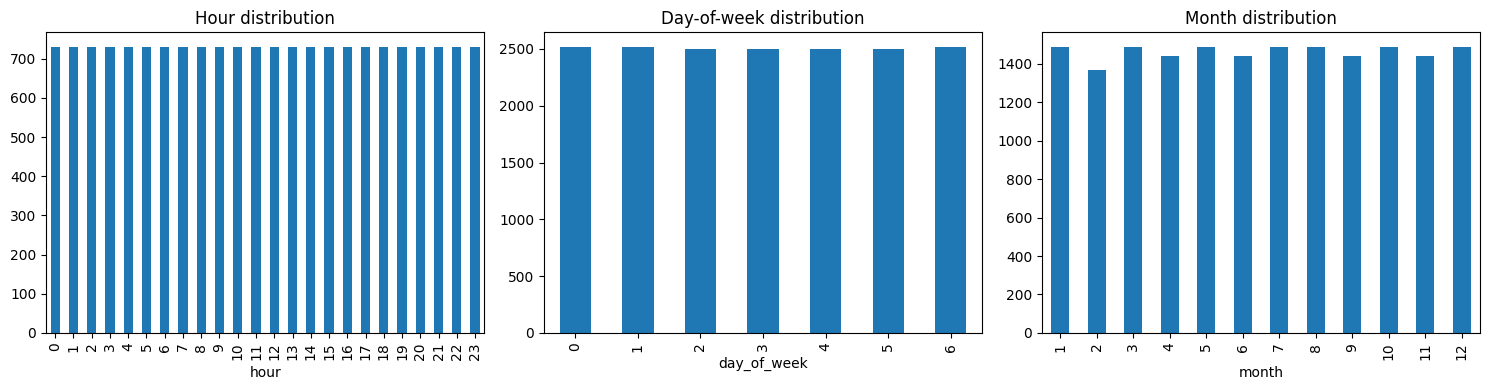

In [16]:
temp_check = data.copy()
temp_check["hour"] = temp_check.index.hour
temp_check["day_of_week"] = temp_check.index.dayofweek
temp_check["month"] = temp_check.index.month

hour_counts = temp_check["hour"].value_counts().sort_index()
dow_counts = temp_check["day_of_week"].value_counts().sort_index()
month_counts = temp_check["month"].value_counts().sort_index()

print("Hour distribution:")
print(hour_counts)
print("\nDay-of-week distribution (0=Monday):")
print(dow_counts)
print("\nMonth distribution:")
print(month_counts)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
hour_counts.plot(kind="bar", ax=axes[0], title="Hour distribution")
dow_counts.plot(kind="bar", ax=axes[1], title="Day-of-week distribution")
month_counts.plot(kind="bar", ax=axes[2], title="Month distribution")
plt.tight_layout()
plt.show()

26 — Cyclical Encoding Validation: Checks that the sin/cos transformation of cyclical features (like hour or month) actually preserves or improves their relationship with PM2.5 compared to the raw values.


In [17]:
enc_check = data.copy()
enc_check["hour"] = enc_check.index.hour
enc_check["month"] = enc_check.index.month
enc_check["wind_dxn"] = enc_check["wind_direction_10m"]
enc_check["hour_sin"] = np.sin(2*np.pi*enc_check["hour"]/24)
enc_check["hour_cos"] = np.cos(2*np.pi*enc_check["hour"]/24)
enc_check["month_sin"] = np.sin(2*np.pi*enc_check["month"]/12)
enc_check["month_cos"] = np.cos(2*np.pi*enc_check["month"]/12)
enc_check["wind_dxn_sin"] = np.sin(2*np.pi*enc_check["wind_dxn"]/360)
enc_check["wind_dxn_cos"] = np.cos(2*np.pi*enc_check["wind_dxn"]/360)

print("Correlation with pm2_5:")
print("raw hour       :", enc_check["hour"].corr(enc_check["pm2_5"]))
print("hour_sin       :", enc_check["hour_sin"].corr(enc_check["pm2_5"]))
print("hour_cos       :", enc_check["hour_cos"].corr(enc_check["pm2_5"]))
print("raw month      :", enc_check["month"].corr(enc_check["pm2_5"]))
print("month_sin      :", enc_check["month_sin"].corr(enc_check["pm2_5"]))
print("month_cos      :", enc_check["month_cos"].corr(enc_check["pm2_5"]))
print("raw wind dxn   :", enc_check["wind_dxn"].corr(enc_check["pm2_5"]))
print("wind_dxn_sin   :", enc_check["wind_dxn_sin"].corr(enc_check["pm2_5"]))
print("wind_dxn_cos   :", enc_check["wind_dxn_cos"].corr(enc_check["pm2_5"]))

Correlation with pm2_5:
raw hour       : 0.055666275941760684
hour_sin       : -0.031577968387488435
hour_cos       : 0.2503847242451869
raw month      : -0.06698350045417437
month_sin      : 0.27681515373165727
month_cos      : 0.38718902383778747
raw wind dxn   : -0.10915978897362151
wind_dxn_sin   : 0.09582105669330435
wind_dxn_cos   : -0.2381289877498882


27 — Lag Feature Distribution Analysis: Visualizes how correlation strength decays as lag distance increases, confirming the lag features behave as expected.


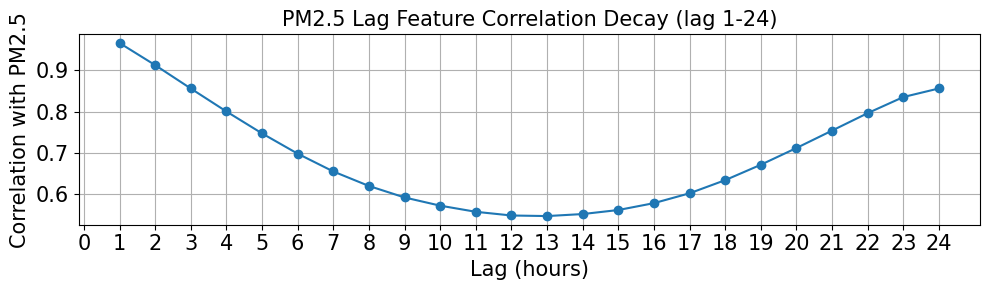

lag_1: 0.9656
lag_2: 0.9122
lag_3: 0.8557
lag_4: 0.8003
lag_5: 0.7473
lag_6: 0.6984
lag_7: 0.6554
lag_8: 0.6204
lag_9: 0.5927
lag_10: 0.5729
lag_11: 0.5581
lag_12: 0.5492
lag_13: 0.5478
lag_14: 0.5526
lag_15: 0.5624
lag_16: 0.5790
lag_17: 0.6028
lag_18: 0.6345
lag_19: 0.6717
lag_20: 0.7121
lag_21: 0.7542
lag_22: 0.7963
lag_23: 0.8352
lag_24: 0.8559


In [61]:
lag_range = range(1, 25)
lag_corrs_full = {i: data["pm2_5"].autocorr(lag=i) for i in lag_range}

plt.figure(figsize=(10, 3))
plt.plot(list(lag_corrs_full.keys()), list(lag_corrs_full.values()), marker="o")
plt.title("PM2.5 Lag Feature Correlation Decay (lag 1-24)", fontsize=15)
plt.xlabel("Lag (hours)", fontsize=15)
plt.ylabel("Correlation with PM2.5", fontsize=15)
plt.xticks(range(0, 25), fontsize=15)
plt.yticks(fontsize=15)
plt.grid(True)
plt.tight_layout()
plt.show()

for lag, corr in lag_corrs_full.items():
    print(f"lag_{lag}: {corr:.4f}")

28 — Train-Test Distribution Comparison: Statistically compares the train and test sets' distributions to check whether they represent different conditions (e.g., different seasons), which would bias evaluation.


      month_sin : KS stat = 0.6207, p-value = 0
      month_cos : KS stat = 0.3166, p-value = 1.367e-250
          pm2_5 : KS stat = 0.1740, p-value = 9.023e-75
 temperature_2m : KS stat = 0.0617, p-value = 9.999e-10


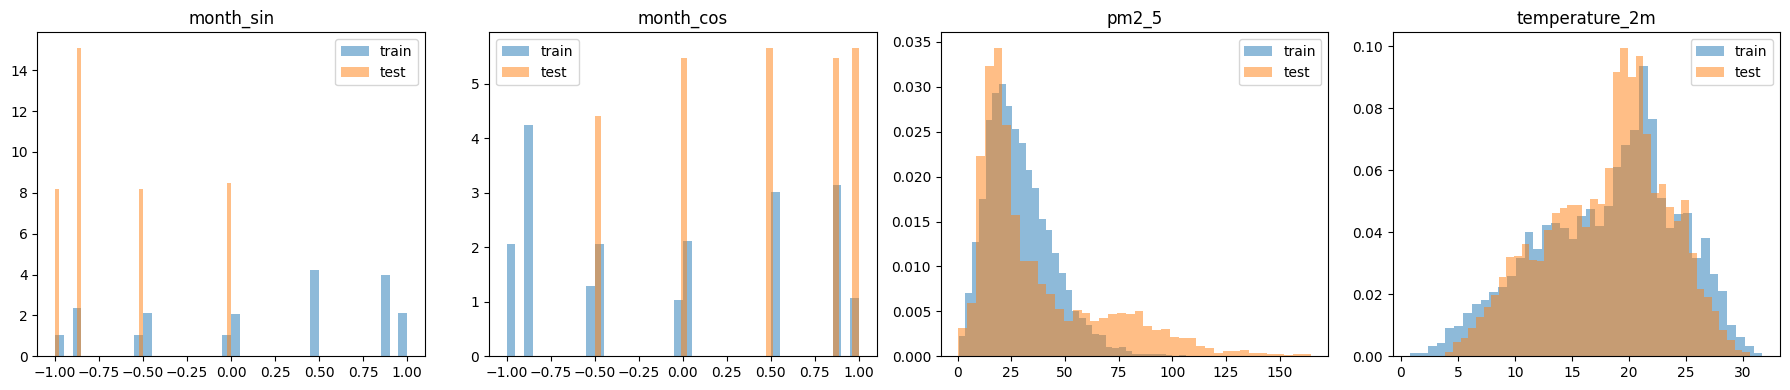

In [19]:
split = int(np.ceil(0.8 * len(data)))
train, test = data.iloc[:split], data.iloc[split:]

train_month = train.index.month
test_month = test.index.month

train_month_sin = np.sin(2*np.pi*train_month/12)
train_month_cos = np.cos(2*np.pi*train_month/12)
test_month_sin  = np.sin(2*np.pi*test_month/12)
test_month_cos  = np.cos(2*np.pi*test_month/12)

check_pairs = {
    "month_sin": (train_month_sin, test_month_sin),
    "month_cos": (train_month_cos, test_month_cos),
    "pm2_5": (train["pm2_5"], test["pm2_5"]),
    "temperature_2m": (train["temperature_2m"], test["temperature_2m"]),
}

for name, (tr, te) in check_pairs.items():
    stat, p = ks_2samp(tr, te)
    print(f"{name:>15} : KS stat = {stat:.4f}, p-value = {p:.4g}")

fig, axes = plt.subplots(1, len(check_pairs), figsize=(18, 4))
for i, (name, (tr, te)) in enumerate(check_pairs.items()):
    axes[i].hist(tr, bins=40, alpha=0.5, label="train", density=True)
    axes[i].hist(te, bins=40, alpha=0.5, label="test", density=True)
    axes[i].set_title(name)
    axes[i].legend()
plt.tight_layout()
plt.show()

29 — Baseline Forecast Analysis: Computes a naive "just predict the last value" forecast to give a minimum bar that any real model should beat.


In [20]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

y_test = test["pm2_5"].reset_index(drop=True)
y_naive = y_test.shift(1)

rmse = root_mean_squared_error(y_test[1:], y_naive[1:])
mae = mean_absolute_error(y_test[1:], y_naive[1:])
r2 = r2_score(y_test[1:], y_naive[1:])

print(f"Naive persistence baseline (lag-1) on test set:")
print(f"RMSE: {rmse:.4f}  MAE: {mae:.4f}  R2: {r2:.4f}")

Naive persistence baseline (lag-1) on test set:
RMSE: 7.9017  MAE: 3.8794  R2: 0.9301


30 — Extreme Pollution Event Analysis: Isolates the worst pollution events and examines when they happen and what conditions (season, hour, pollutants) accompany them.


Extreme event threshold (95th pctile): 68.00
Number of extreme events: 879

Hour-of-day distribution of extreme events:
hour
0     64
1     60
2     56
3     48
4     41
5     39
6     43
7     59
8     57
9     11
10     5
11     3
12     4
13     5
14     5
15     6
16     8
17    19
18    26
19    39
20    55
21    71
22    82
23    73
Name: count, dtype: int64


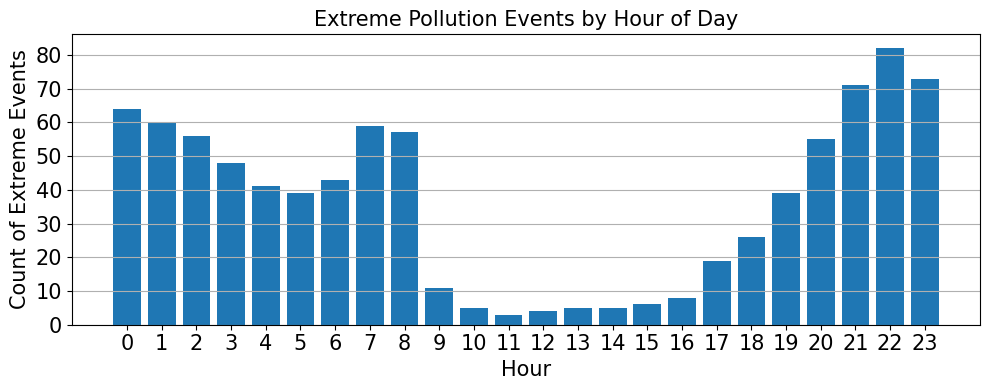


Month distribution of extreme events:
month
1     200
2      40
3      11
11    241
12    387
Name: count, dtype: int64


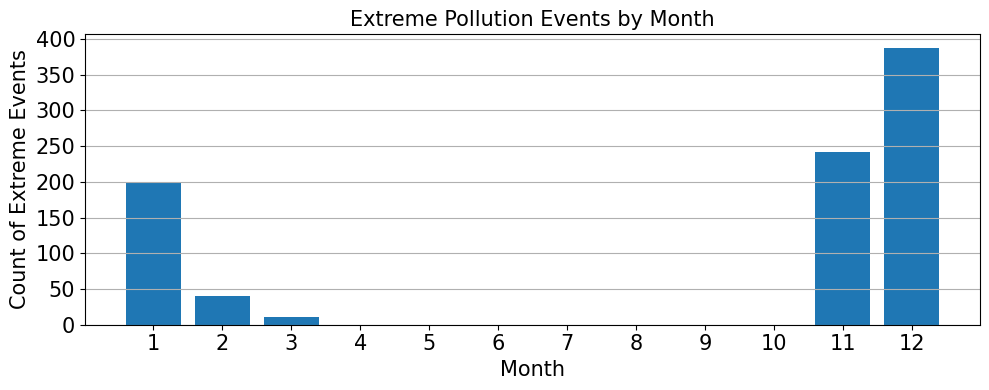


Mean pollutant levels during extreme events vs overall:
                  extreme_mean  overall_mean
carbon_monoxide    1356.234357    612.107045
nitrogen_dioxide     30.011263     12.572458
sulphur_dioxide      16.324915      6.137454
ozone                75.806598     96.054891


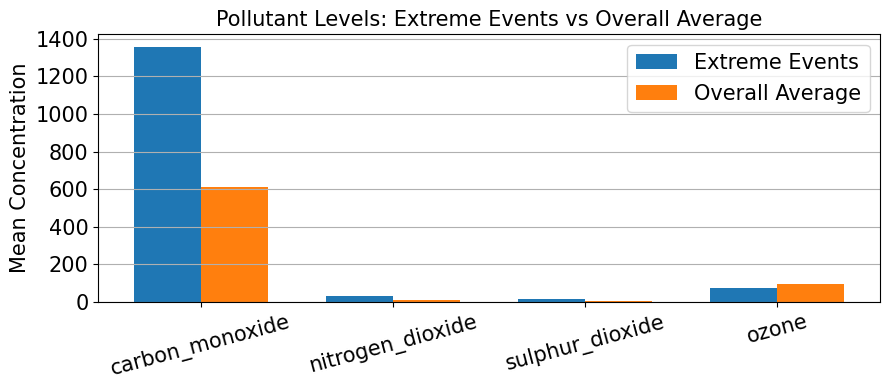

In [45]:
threshold = data["pm2_5"].quantile(0.95)
extreme = data[data["pm2_5"] >= threshold].copy()
extreme["hour"] = extreme.index.hour
extreme["month"] = extreme.index.month

print(f"Extreme event threshold (95th pctile): {threshold:.2f}")
print(f"Number of extreme events: {len(extreme)}\n")

# --- Hour-of-day distribution ---
hour_counts = extreme["hour"].value_counts().sort_index()
print("Hour-of-day distribution of extreme events:")
print(hour_counts)

plt.figure(figsize=(10, 4))
plt.bar(hour_counts.index, hour_counts.values)
plt.title("Extreme Pollution Events by Hour of Day", fontsize=15)
plt.xlabel("Hour", fontsize=15)
plt.ylabel("Count of Extreme Events", fontsize=15)
plt.xticks(range(0, 24), fontsize=15)
plt.yticks(fontsize=15)
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

# --- Month distribution ---
month_counts = extreme["month"].value_counts().sort_index()
print("\nMonth distribution of extreme events:")
print(month_counts)

plt.figure(figsize=(10, 4))
plt.bar(month_counts.index, month_counts.values)
plt.title("Extreme Pollution Events by Month", fontsize=15)
plt.xlabel("Month", fontsize=15)
plt.ylabel("Count of Extreme Events", fontsize=15)
plt.xticks(range(1, 13), fontsize=15)
plt.yticks(fontsize=15)
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

# --- Pollutant comparison: extreme vs overall ---
pollutants = ["carbon_monoxide", "nitrogen_dioxide", "sulphur_dioxide", "ozone"]
comparison = pd.DataFrame({
    "extreme_mean": extreme[pollutants].mean(),
    "overall_mean": data[pollutants].mean()
})
print("\nMean pollutant levels during extreme events vs overall:")
print(comparison)

x = np.arange(len(pollutants))
width = 0.35

plt.figure(figsize=(9, 4))
plt.bar(x - width/2, comparison["extreme_mean"], width, label="Extreme Events")
plt.bar(x + width/2, comparison["overall_mean"], width, label="Overall Average")
plt.xticks(x, pollutants, rotation=15, fontsize=15)
plt.yticks(fontsize=15)
plt.ylabel("Mean Concentration", fontsize=15)
plt.title("Pollutant Levels: Extreme Events vs Overall Average", fontsize=15)
plt.legend(fontsize=15)
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

31 — Feature Importance Pre-Analysis: Uses a quick tree-based model to rank which features contribute most to predicting PM2.5, as an initial sanity check before deeper analysis.


pm2_5                      0.929430
pm10                       0.016633
hour_sin                   0.007601
hour_cos                   0.004192
pm2_5_lag_1                0.003368
                             ...   
surface_pressure_lag_9     0.000123
surface_pressure_lag_10    0.000110
dow_sin                    0.000108
dow_cos                    0.000066
month_sin                  0.000063
Length: 105, dtype: float64


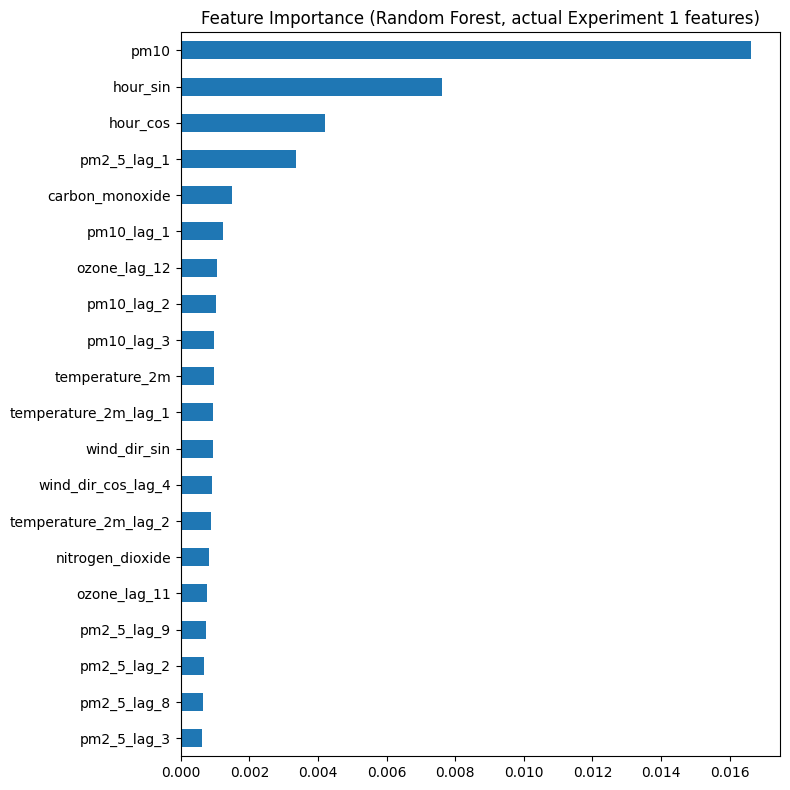

In [57]:
from sklearn.ensemble import RandomForestRegressor

# Using your actual Experiment 1 tree-preprocessed data, not rebuilt features
X_train_tree = pd.read_csv("../../../data/processed/1_hour_prediction/X_train_tree.csv")
y_train = pd.read_csv("../../../data/processed/1_hour_prediction/y_train.csv").squeeze()

rf_importance = RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_leaf=5, n_jobs=-1, random_state=42)
rf_importance.fit(X_train_tree, y_train)

importances = pd.Series(rf_importance.feature_importances_, index=X_train_tree.columns).sort_values(ascending=False)
print(importances)

plt.figure(figsize=(8, 8))
importances_without_pm25 = importances.drop("pm2_5")
importances_without_pm25[:20].plot(kind="barh")
plt.title("Feature Importance (Random Forest, actual Experiment 1 features)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

32 — SHAP/Explainability Analysis: Quantifies, per feature, exactly how much and in what direction it pushes individual PM2.5 predictions, giving the most rigorous "what actually drives this" answer.

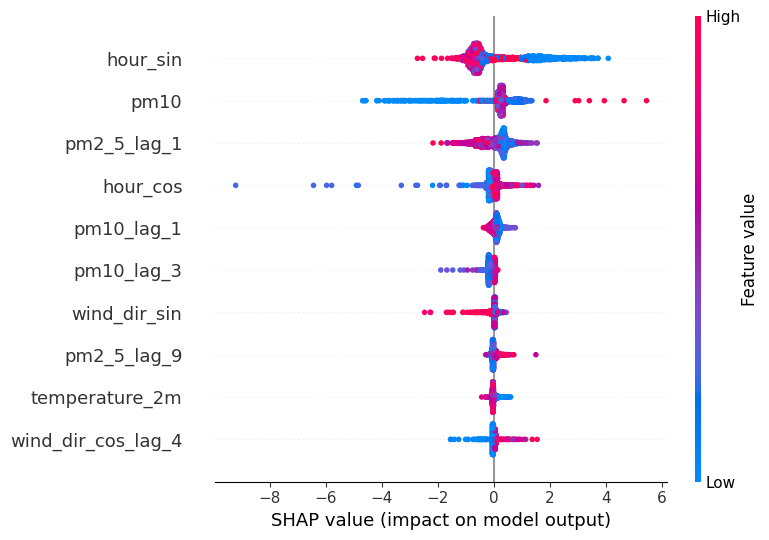

SHAP summary (text form):
                         mean_abs_shap  direction_corr
pm2_5                        11.540428        0.996635
hour_sin                      0.883214       -0.541380
pm10                          0.530242        0.291890
pm2_5_lag_1                   0.376449       -0.700040
hour_cos                      0.159740        0.283038
...                                ...             ...
surface_pressure_lag_2        0.005951        0.153605
surface_pressure_lag_10       0.004982       -0.252798
dow_sin                       0.004198       -0.098596
month_sin                     0.003845        0.421978
dow_cos                       0.003200        0.313949

[105 rows x 2 columns]

direction_corr > 0 : higher feature value -> pushes prediction UP
direction_corr < 0 : higher feature value -> pushes prediction DOWN


In [58]:
import shap

# SHAP calculation (unchanged)
explainer = shap.TreeExplainer(rf_importance)
X_sample = X_train_tree.sample(2000, random_state=42)
shap_values = explainer.shap_values(X_sample)

# -------------------------------
# Exclude PM2.5 only from plotting
# -------------------------------
feature_to_exclude = "pm2_5"   # Change this if your column is named differently

plot_columns = [col for col in X_sample.columns if col != feature_to_exclude]

X_plot = X_sample[plot_columns]

# Select SHAP values for the remaining features
shap_values_plot = shap_values[:, [X_sample.columns.get_loc(col) for col in plot_columns]]

# Plot without PM2.5
shap.summary_plot(shap_values_plot, X_plot, show=True, max_display=10)

# ---------------------------------------
# SHAP importance calculations (unchanged)
# ---------------------------------------
mean_abs_shap = (
    pd.Series(np.abs(shap_values).mean(axis=0), index=X_train_tree.columns)
    .sort_values(ascending=False)
)

direction = pd.Series(
    [
        np.corrcoef(X_sample.iloc[:, i], shap_values[:, i])[0, 1]
        for i in range(X_sample.shape[1])
    ],
    index=X_train_tree.columns,
)

summary_table = pd.DataFrame({
    "mean_abs_shap": mean_abs_shap,
    "direction_corr": direction.reindex(mean_abs_shap.index)
})

print("SHAP summary (text form):")
print(summary_table)
print("\ndirection_corr > 0 : higher feature value -> pushes prediction UP")
print("direction_corr < 0 : higher feature value -> pushes prediction DOWN")

pm2_5                         0.586665
pm10                          0.075202
carbon_monoxide               0.036910
month_sin                     0.010964
temperature_2m                0.008369
                                ...   
pm2_5_lag_3                   0.001373
relative_humidity_2m_lag_5    0.001319
nitrogen_dioxide_lag_2        0.001253
hour_cos                      0.000806
hour_sin                      0.000545
Length: 105, dtype: float64


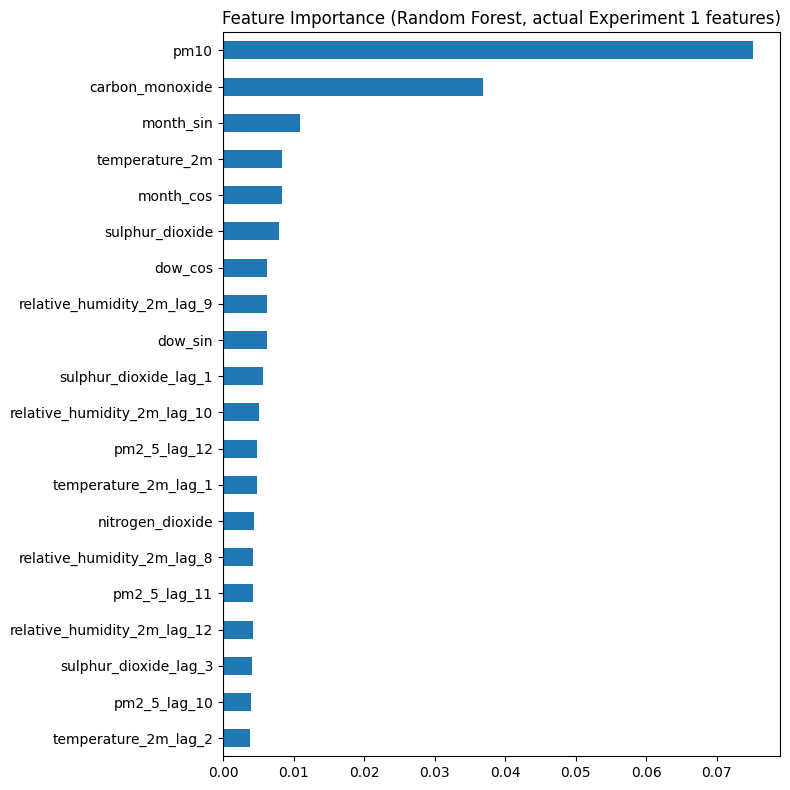

In [59]:
from sklearn.ensemble import RandomForestRegressor

# Using your actual Experiment 1 tree-preprocessed data, not rebuilt features
X_train_tree = pd.read_csv("../../../data/processed/24_hour_prediction/X_train_tree.csv")
y_train = pd.read_csv("../../../data/processed/24_hour_prediction/y_train.csv").squeeze()

rf_importance = RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_leaf=5, n_jobs=-1, random_state=42)
rf_importance.fit(X_train_tree, y_train)

importances = pd.Series(rf_importance.feature_importances_, index=X_train_tree.columns).sort_values(ascending=False)
print(importances)

plt.figure(figsize=(8, 8))
importances_without_pm25 = importances.drop("pm2_5")
importances_without_pm25[:20].plot(kind="barh")
plt.title("Feature Importance (Random Forest, actual Experiment 1 features)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

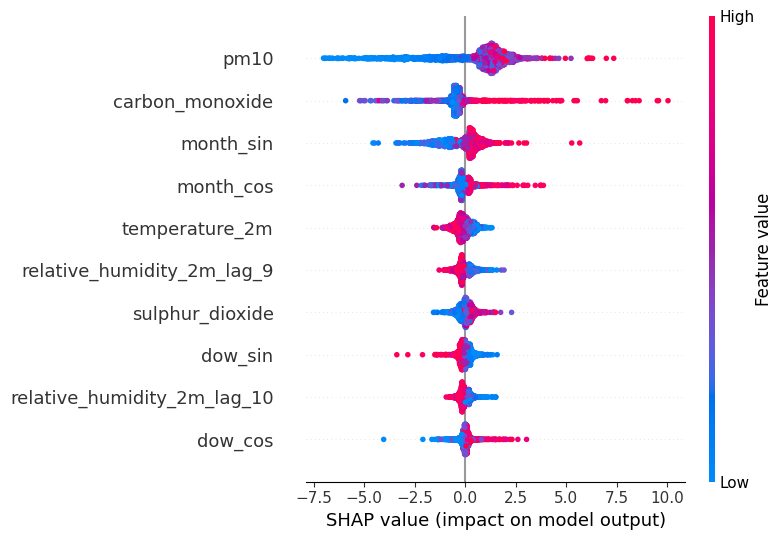

SHAP summary (text form):
                            mean_abs_shap  direction_corr
pm2_5                            7.901278        0.969172
pm10                             1.620515        0.659391
carbon_monoxide                  0.693999        0.609648
month_sin                        0.679095        0.792980
month_cos                        0.339192        0.577343
...                                   ...             ...
wind_dir_cos_lag_3               0.021732       -0.311244
wind_dir_cos_lag_4               0.021671       -0.146603
nitrogen_dioxide_lag_2           0.021036        0.191041
relative_humidity_2m_lag_5       0.019240       -0.393062
hour_sin                         0.011474       -0.061187

[105 rows x 2 columns]

direction_corr > 0 : higher feature value -> pushes prediction UP
direction_corr < 0 : higher feature value -> pushes prediction DOWN


In [60]:
import shap

# SHAP calculation (unchanged)
explainer = shap.TreeExplainer(rf_importance)
X_sample = X_train_tree.sample(2000, random_state=42)
shap_values = explainer.shap_values(X_sample)

# -------------------------------
# Exclude PM2.5 only from plotting
# -------------------------------
feature_to_exclude = "pm2_5"   # Change this if your column is named differently

plot_columns = [col for col in X_sample.columns if col != feature_to_exclude]

X_plot = X_sample[plot_columns]

# Select SHAP values for the remaining features
shap_values_plot = shap_values[:, [X_sample.columns.get_loc(col) for col in plot_columns]]

# Plot without PM2.5
shap.summary_plot(shap_values_plot, X_plot, show=True, max_display=10)

# ---------------------------------------
# SHAP importance calculations (unchanged)
# ---------------------------------------
mean_abs_shap = (
    pd.Series(np.abs(shap_values).mean(axis=0), index=X_train_tree.columns)
    .sort_values(ascending=False)
)

direction = pd.Series(
    [
        np.corrcoef(X_sample.iloc[:, i], shap_values[:, i])[0, 1]
        for i in range(X_sample.shape[1])
    ],
    index=X_train_tree.columns,
)

summary_table = pd.DataFrame({
    "mean_abs_shap": mean_abs_shap,
    "direction_corr": direction.reindex(mean_abs_shap.index)
})

print("SHAP summary (text form):")
print(summary_table)
print("\ndirection_corr > 0 : higher feature value -> pushes prediction UP")
print("direction_corr < 0 : higher feature value -> pushes prediction DOWN")